# Exploratory Data Analysis

This notebook explores the validated environmental data to understand
weather and air-quality patterns across the monitored cities.

The analysis focuses on:

- Weather and air-quality distributions
- City-level pollution patterns
- Temperature, humidity, wind, and rainfall patterns
- PM2.5, PM10, and AQI trends
- Relationships between environmental variables
- Differences across cities and time periods

The goal is to identify meaningful patterns and observations that can
support the advanced analysis and business insights.

In [1]:
import pandas as pd
import numpy as np
import pyodbc
from datetime import datetime, timezone

from src.database.sql_server import get_sql_connection

conn = get_sql_connection()

print("SQL Server connected successfully!")

cursor = conn.cursor()

cursor.execute("SELECT DB_NAME()")

database_name = cursor.fetchone()[0]

print("Connected database:", database_name)

cursor.close()

SQL Server connected successfully!
Connected database: ClimateImpactDW


### Section 1 — Load Gold

In [2]:
query = """
SELECT *
FROM gold.fact_environment
"""

df = pd.read_sql(query, conn)

df["observation_timestamp_utc"] = pd.to_datetime(
    df["observation_timestamp_utc"]
)

C:\Users\admin\AppData\Local\Temp\ipykernel_1964\3931751477.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


### Section 2 — Basic statistics

In [3]:
numeric_columns = [
    "temperature_c",
    "feels_like_c",
    "humidity_pct",
    "pressure_hpa",
    "visibility_m",
    "wind_speed_mps",
    "rainfall_1h_mm",
    "cloudiness_pct",
    "openweather_aqi",
    "pm2_5",
    "pm10",
    "co",
    "no",
    "no2",
    "o3",
    "so2",
    "nh3"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_c,14613.0,28.923049,4.445296,16.37,26.19,29.00,31.00,44.01
feels_like_c,14613.0,32.749515,6.522973,16.16,26.39,33.75,37.47,49.01
humidity_pct,14613.0,72.092863,16.652055,16.00,62.00,74.00,84.00,100.00
pressure_hpa,14613.0,1006.179019,5.337127,996.00,1001.00,1006.00,1010.00,1025.00
visibility_m,14611.0,9868.342345,804.209236,1171.00,10000.00,10000.00,10000.00,10000.00
wind_speed_mps,14613.0,4.379203,2.978790,0.00,2.57,4.12,5.66,34.80
rainfall_1h_mm,4006.0,1.108759,2.158421,0.10,0.17,0.41,1.17,48.63
cloudiness_pct,14613.0,75.982344,32.228768,0.00,61.00,93.00,100.00,100.00
openweather_aqi,14613.0,1.975433,1.110269,1.00,1.00,2.00,3.00,5.00
pm2_5,14613.0,17.560310,19.624515,0.89,4.22,9.39,24.21,112.33


### Section 3 — City-level summary

In [4]:
city_summary = (
    df.groupby("city_key")
      .agg(
          observations=("observation_id", "count"),
          avg_temperature=("temperature_c", "mean"),
          avg_humidity=("humidity_pct", "mean"),
          avg_aqi=("openweather_aqi", "mean"),
          avg_pm25=("pm2_5", "mean"),
          avg_pm10=("pm10", "mean"),
          avg_wind_speed=("wind_speed_mps", "mean")
      )
      .reset_index()
)

city_summary

,city_key,observations,avg_temperature,avg_humidity,avg_aqi,avg_pm25,avg_pm10,avg_wind_speed
0,1,731,29.999808,57.259918,1.184679,6.690014,14.279822,4.042599
1,2,731,26.270424,70.729138,1.062927,6.387428,9.540684,4.973434
2,3,731,25.016881,87.300958,1.357045,8.431108,9.981108,3.842763
3,4,731,29.040930,82.502052,2.372093,24.808044,27.418098,2.706156
4,5,731,32.111067,70.373461,1.759234,13.308564,16.939275,4.058755
5,6,730,31.984384,71.658904,2.967123,30.726288,71.720466,3.148781
6,7,730,40.375726,33.265753,4.917808,71.149945,271.087466,5.304137
7,8,731,30.464323,84.861833,1.499316,9.118728,10.429808,1.960670
8,9,731,27.878413,70.440492,1.116279,3.097934,4.153721,10.201122
9,10,731,30.587674,63.954856,2.112175,12.906922,31.405869,3.452148


### Section 4 — Temperature distribution

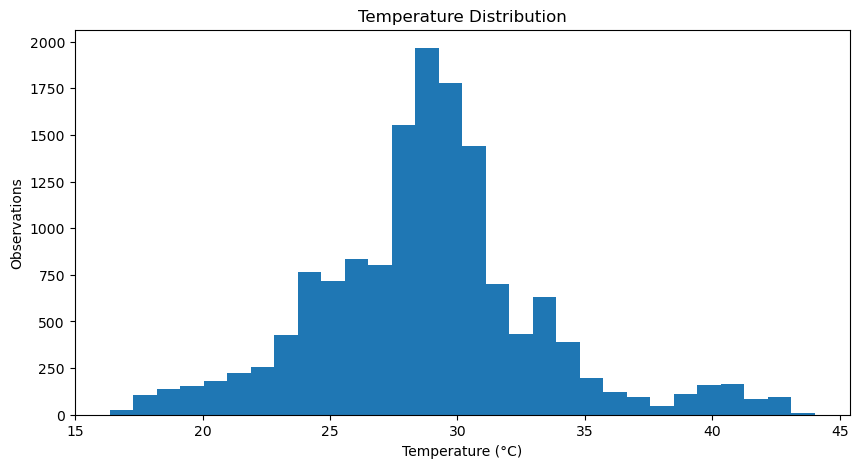

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["temperature_c"].dropna(),
    bins=30
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Observations")

plt.show()

### Section 5 — PM2.5 distribution

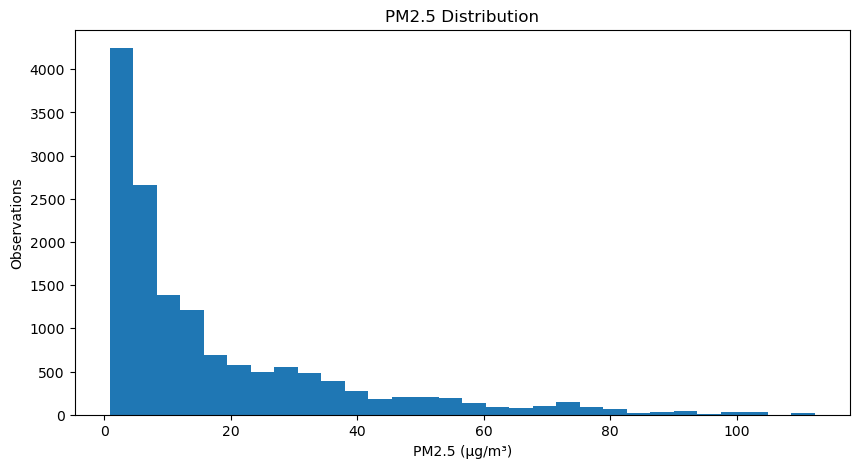

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["pm2_5"].dropna(),
    bins=30
)

plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5 (μg/m³)")
plt.ylabel("Observations")

plt.show()

### Section 6 — Temperature over time

C:\Users\admin\AppData\Local\Temp\ipykernel_1964\3370839076.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")["temperature_c"]


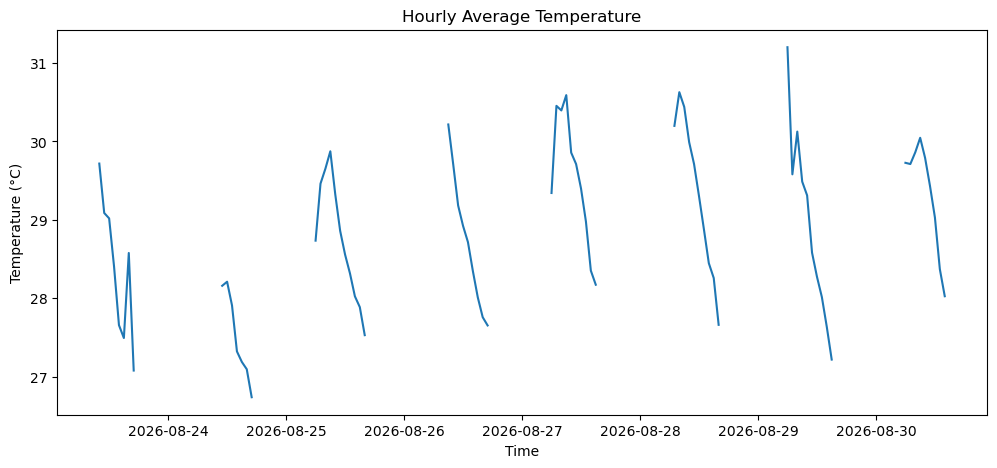

In [7]:
temperature_trend = (
    df.set_index("observation_timestamp_utc")
      .resample("1H")["temperature_c"]
      .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    temperature_trend.index,
    temperature_trend.values
)

plt.title("Hourly Average Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

### Section 7 — PM2.5 over time

C:\Users\admin\AppData\Local\Temp\ipykernel_1964\3318160336.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")["pm2_5"]


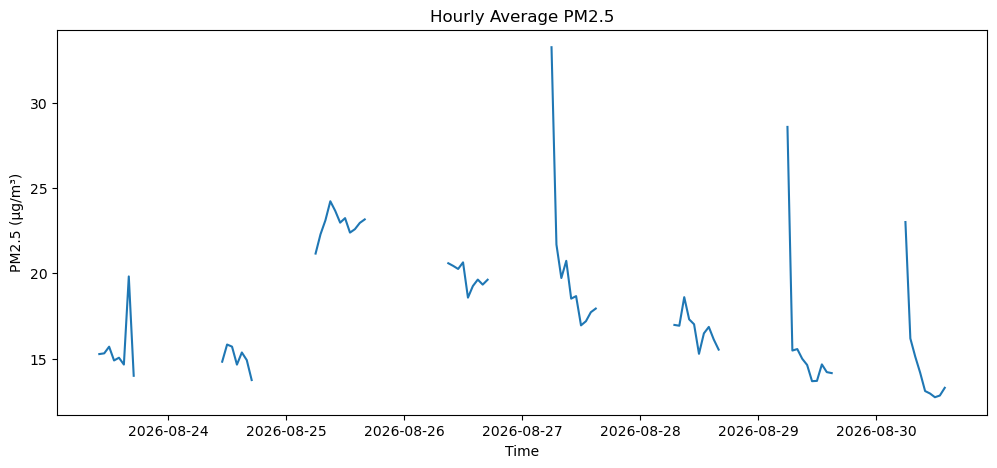

In [8]:
pm25_trend = (
    df.set_index("observation_timestamp_utc")
      .resample("1H")["pm2_5"]
      .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    pm25_trend.index,
    pm25_trend.values
)

plt.title("Hourly Average PM2.5")
plt.xlabel("Time")
plt.ylabel("PM2.5 (μg/m³)")

plt.show()

### Section 8 — AQI categories

In [9]:
aqi_distribution = (
    df["aqi_category"]
    .value_counts(dropna=False)
)

aqi_distribution

aqi_category
Good         6400
Fair         4205
Moderate     2732
Very Poor     757
Poor          519
Name: count, dtype: int64

### Section 9 — Correlation matrix

In [10]:
correlation_columns = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "wind_speed_mps",
    "rainfall_1h_mm",
    "openweather_aqi",
    "pm2_5",
    "pm10"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

correlation_matrix

,temperature_c,humidity_pct,pressure_hpa,wind_speed_mps,rainfall_1h_mm,openweather_aqi,pm2_5,pm10
temperature_c,1.000000,-0.532068,-0.601577,0.026649,-0.047310,0.582842,0.606801,0.664855
humidity_pct,-0.532068,1.000000,-0.033193,-0.282033,0.112368,-0.249460,-0.201223,-0.478870
pressure_hpa,-0.601577,-0.033193,1.000000,0.206765,-0.102170,-0.555690,-0.564092,-0.382731
wind_speed_mps,0.026649,-0.282033,0.206765,1.000000,-0.036997,-0.144621,-0.154675,-0.017759
rainfall_1h_mm,-0.047310,0.112368,-0.102170,-0.036997,1.000000,0.012952,0.008249,-0.006542
openweather_aqi,0.582842,-0.249460,-0.555690,-0.144621,0.012952,1.000000,0.916698,0.763822
pm2_5,0.606801,-0.201223,-0.564092,-0.154675,0.008249,0.916698,1.000000,0.810031
pm10,0.664855,-0.478870,-0.382731,-0.017759,-0.006542,0.763822,0.810031,1.000000
